<a href="https://colab.research.google.com/github/Swethashri-lab/Bioinformatics_basic/blob/main/advanced_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import pandas as pd
gene_info = pd.DataFrame ({
    "gene_name" : ["BRCA1", "TP53", "INS", "EGFR", "MYC"],
    "length"    : [7088, 2629, 465, 3633, 1184],
    "gc_content": [42.5, 58.3, 55.3, 60.1, 59.8],
    "chromosome": [17, 11, 11, 7, 8]

})

expression_table = pd.DataFrame ({
    "gene_name"  : ["BRCA1", "TP53", "INS", "EGFR", "MYC"],
    "normal_expr": [150.5, 890.3, 45.2, 210.8, 340.1],
    "cancer_expr": [89.3, 234.5, 67.8, 1205.6, 2340.8],
})
print("table 1 - gene_info : ")
print(gene_info)
print("Table 2 - gene_expression : ")
print(expression_table)


table 1 - gene_info : 
  gene_name  length  gc_content  chromosome
0     BRCA1    7088        42.5          17
1      TP53    2629        58.3          11
2       INS     465        55.3          11
3      EGFR    3633        60.1           7
4       MYC    1184        59.8           8
Table 2 - gene_expression : 
  gene_name  normal_expr  cancer_expr
0     BRCA1        150.5         89.3
1      TP53        890.3        234.5
2       INS         45.2         67.8
3      EGFR        210.8       1205.6
4       MYC        340.1       2340.8


In [6]:
merged_table = pd.merge(
    gene_info,
    expression_table,
    on = "gene_name"

)
print("the merged table is : ", merged_table)
print(merged_table.shape)


the merged table is :    gene_name  length  gc_content  chromosome  normal_expr  cancer_expr
0     BRCA1    7088        42.5          17        150.5         89.3
1      TP53    2629        58.3          11        890.3        234.5
2       INS     465        55.3          11         45.2         67.8
3      EGFR    3633        60.1           7        210.8       1205.6
4       MYC    1184        59.8           8        340.1       2340.8
(5, 6)


In [8]:
merged_table["fold_change"] = round(merged_table["cancer_expr"]/merged_table["normal_expr"],2)
import numpy as np
merged_table["log2_fc"] = round(np.log2(merged_table["fold_change"]),2)
merged_table["regulation"] = "unchanged"
merged_table.loc[merged_table["log2_fc"] > 1,  "regulation"] = "upregulated ⬆️"
merged_table.loc[merged_table["log2_fc"] < -1, "regulation"] = "downregulated ⬇️"
print(merged_table)

  gene_name  length  gc_content  chromosome  normal_expr  cancer_expr  \
0     BRCA1    7088        42.5          17        150.5         89.3   
1      TP53    2629        58.3          11        890.3        234.5   
2       INS     465        55.3          11         45.2         67.8   
3      EGFR    3633        60.1           7        210.8       1205.6   
4       MYC    1184        59.8           8        340.1       2340.8   

   fold_change  log2_fc        regulation  
0         0.59    -0.76         unchanged  
1         0.26    -1.94  downregulated ⬇️  
2         1.50     0.58         unchanged  
3         5.72     2.52    upregulated ⬆️  
4         6.88     2.78    upregulated ⬆️  


In [11]:
# CREATE MULTI-CONDITION EXPRESSION DATA

import pandas as pd
import numpy as np

expression = pd.DataFrame({
    "gene"      : ["BRCA1","BRCA1","BRCA1",
                   "TP53", "TP53", "TP53",
                   "EGFR", "EGFR", "EGFR",
                   "MYC",  "MYC",  "MYC"],
    # ↑ each gene appears 3 times (3 conditions)

    "condition" : ["normal","cancer","treated"] * 4,
    # ↑ * 4 repeats the list 4 times
    # ↑ covers all 4 genes

    "expression": [150.5, 890.3, 234.5,
                   45.2,  67.8,  23.1,
                   210.8, 1205.6, 456.7,
                   340.1, 2340.8, 890.2],
    # ↑ expression value for each gene+condition

    "sample_size": [3, 3, 3,
                    3, 3, 3,
                    3, 3, 3,
                    3, 3, 3]
})

print("Expression Data:")
print(expression)
print(f"\nShape: {expression.shape}")

Expression Data:
     gene condition  expression  sample_size
0   BRCA1    normal       150.5            3
1   BRCA1    cancer       890.3            3
2   BRCA1   treated       234.5            3
3    TP53    normal        45.2            3
4    TP53    cancer        67.8            3
5    TP53   treated        23.1            3
6    EGFR    normal       210.8            3
7    EGFR    cancer      1205.6            3
8    EGFR   treated       456.7            3
9     MYC    normal       340.1            3
10    MYC    cancer      2340.8            3
11    MYC   treated       890.2            3

Shape: (12, 4)


In [15]:
condition_avg = expression.groupby("condition")["expression"].mean().round(2)
print(condition_avg)
print()

# Which condition has highest expression?
highest_condition = condition_avg.idxmax()
print(f"Highest expression in: {highest_condition}")
print()


condition
cancer     1126.12
normal      186.65
treated     401.12
Name: expression, dtype: float64

Highest expression in: cancer



In [16]:
grouped_table = expression.groupby("condition")["expression"].max()
print(grouped_table)
highest_max = grouped_table.idxmax()
print(highest_max)


condition
cancer     2340.8
normal      340.1
treated     890.2
Name: expression, dtype: float64
cancer


In [1]:
import pandas as pd
import numpy as np

# SET RANDOM SEED — makes random numbers reproducible
np.random.seed(42)
# ↑ seed(42) means everyone gets same "random" numbers
# ↑ important in science — results must be reproducible
# ↑ any number works — 42 is just commonly used

# GENE LIST
genes = ["BRCA1", "TP53", "EGFR", "MYC", "INS",
         "VEGF", "CDK2", "PTEN", "RB1", "HER2"]
# ↑ 10 real cancer-related genes

# SIMULATE EXPRESSION VALUES
# Normal samples — baseline expression
normal_s1 = [150, 890, 210, 340, 45,
             120, 560, 780, 430, 190]
# ↑ sample 1 normal expression values

normal_s2 = [145, 910, 198, 355, 48,
             115, 545, 800, 445, 185]
# ↑ sample 2 — slightly different (biological variation)

normal_s3 = [160, 875, 225, 330, 42,
             125, 570, 760, 420, 195]
# ↑ sample 3

# Cancer samples — some genes changed
cancer_s1 = [89,  234, 1205, 2340, 68,
             890, 234,  156, 120, 1560]
# ↑ EGFR, MYC, VEGF, HER2 upregulated in cancer

cancer_s2 = [92,  245, 1189, 2290, 71,
             910, 245,  145, 115, 1590]

cancer_s3 = [85,  228, 1220, 2380, 65,
             875, 228,  167, 125, 1540]

# BUILD DATAFRAME
df = pd.DataFrame({
    "gene"      : genes,
    "normal_s1" : normal_s1,
    "normal_s2" : normal_s2,
    "normal_s3" : normal_s3,
    "cancer_s1" : cancer_s1,
    "cancer_s2" : cancer_s2,
    "cancer_s3" : cancer_s3,
})

print("RAW EXPRESSION DATA:")
print("=" * 70)
print(df)
print(f"\nShape: {df.shape}")

RAW EXPRESSION DATA:
    gene  normal_s1  normal_s2  normal_s3  cancer_s1  cancer_s2  cancer_s3
0  BRCA1        150        145        160         89         92         85
1   TP53        890        910        875        234        245        228
2   EGFR        210        198        225       1205       1189       1220
3    MYC        340        355        330       2340       2290       2380
4    INS         45         48         42         68         71         65
5   VEGF        120        115        125        890        910        875
6   CDK2        560        545        570        234        245        228
7   PTEN        780        800        760        156        145        167
8    RB1        430        445        420        120        115        125
9   HER2        190        185        195       1560       1590       1540

Shape: (10, 7)


In [2]:
# CALCULATE MEAN EXPRESSION PER CONDITION

df["normal_mean"] = df[["normal_s1",
                          "normal_s2",
                          "normal_s3"]].mean(axis=1)
# ↑ .mean(axis=1) = calculate mean ACROSS columns
# ↑ axis=1 means "go across each ROW"
# ↑ axis=0 means "go down each COLUMN"
# ↑ result = one average per gene

df["cancer_mean"] = df[["cancer_s1",
                          "cancer_s2",
                          "cancer_s3"]].mean(axis=1)
# ↑ same for cancer samples

df["normal_mean"] = df["normal_mean"].round(2)
df["cancer_mean"] = df["cancer_mean"].round(2)


print("MEAN EXPRESSION PER CONDITION:")
print("=" * 45)
print(df[["gene", "normal_mean", "cancer_mean"]])

MEAN EXPRESSION PER CONDITION:
    gene  normal_mean  cancer_mean
0  BRCA1       151.67        88.67
1   TP53       891.67       235.67
2   EGFR       211.00      1204.67
3    MYC       341.67      2336.67
4    INS        45.00        68.00
5   VEGF       120.00       891.67
6   CDK2       558.33       235.67
7   PTEN       780.00       156.00
8    RB1       431.67       120.00
9   HER2       190.00      1563.33


In [3]:
# FOLD CHANGE ANALYSIS

df["fold_change"] = round(
    df["cancer_mean"] / df["normal_mean"], 2
)
# ↑ how many times changed in cancer vs normal

df["log2_fc"] = round(
    np.log2(df["fold_change"]), 2
)
# ↑ log2 fold change — standard RNA-seq metric
# ↑ positive = upregulated in cancer
# ↑ negative = downregulated in cancer

# LABEL REGULATION
df["regulation"] = "unchanged"
df.loc[df["log2_fc"] >  1, "regulation"] = "upregulated"
df.loc[df["log2_fc"] < -1, "regulation"] = "downregulated"
# ↑ log2FC > 1  = more than 2x up
# ↑ log2FC < -1 = more than 2x down

print("FOLD CHANGE RESULTS:")
print("=" * 65)
print(df[["gene", "normal_mean", "cancer_mean",
          "fold_change", "log2_fc", "regulation"]])
print()

# Count regulation categories
print("REGULATION SUMMARY:")
print(df["regulation"].value_counts())

FOLD CHANGE RESULTS:
    gene  normal_mean  cancer_mean  fold_change  log2_fc     regulation
0  BRCA1       151.67        88.67         0.58    -0.79      unchanged
1   TP53       891.67       235.67         0.26    -1.94  downregulated
2   EGFR       211.00      1204.67         5.71     2.51    upregulated
3    MYC       341.67      2336.67         6.84     2.77    upregulated
4    INS        45.00        68.00         1.51     0.59      unchanged
5   VEGF       120.00       891.67         7.43     2.89    upregulated
6   CDK2       558.33       235.67         0.42    -1.25  downregulated
7   PTEN       780.00       156.00         0.20    -2.32  downregulated
8    RB1       431.67       120.00         0.28    -1.84  downregulated
9   HER2       190.00      1563.33         8.23     3.04    upregulated

REGULATION SUMMARY:
regulation
downregulated    4
upregulated      4
unchanged        2
Name: count, dtype: int64


In [4]:
# FIND TOP DIFFERENTIALLY EXPRESSED GENES

# Sort by absolute log2FC — biggest changes first
df["abs_log2fc"] = df["log2_fc"].abs()
# ↑ .abs() = absolute value (removes negative sign)
# ↑ -2.32 becomes 2.32
# ↑ lets us sort by SIZE of change regardless of direction

top_degs = df.sort_values("abs_log2fc",
                           ascending=False)
# ↑ biggest change first

print("TOP DIFFERENTIALLY EXPRESSED GENES:")
print("=" * 60)
print(top_degs[["gene", "log2_fc",
                "regulation"]].head(6))
# ↑ show top 6

print()

# Separate upregulated and downregulated
upregulated   = df[df["regulation"] == "upregulated"]
downregulated = df[df["regulation"] == "downregulated"]

print(f"Upregulated genes   : {list(upregulated['gene'])}")
print(f"Downregulated genes : {list(downregulated['gene'])}")

TOP DIFFERENTIALLY EXPRESSED GENES:
   gene  log2_fc     regulation
9  HER2     3.04    upregulated
5  VEGF     2.89    upregulated
3   MYC     2.77    upregulated
2  EGFR     2.51    upregulated
7  PTEN    -2.32  downregulated
1  TP53    -1.94  downregulated

Upregulated genes   : ['EGFR', 'MYC', 'VEGF', 'HER2']
Downregulated genes : ['TP53', 'CDK2', 'PTEN', 'RB1']


In [6]:
df_downregulated = df[df["regulation" == downregulated]]
sorted = df_downregulated.sort_values("log2_fc",ascending = True)
print(sorted[["gene","log2_fc"]])

  gene  log2_fc
0  NaN      NaN
1  NaN      NaN
2  NaN      NaN
3  NaN      NaN
4  NaN      NaN
5  NaN      NaN
6  NaN      NaN
7  NaN      NaN
8  NaN      NaN
9  NaN      NaN


In [7]:
import matplotlib.pyplot as plt
# ↑ matplotlib = plotting library
# ↑ pyplot = the specific plotting module
# ↑ as plt = nickname (everyone uses plt)

import pandas as pd
import numpy as np

print("✅ Matplotlib ready!")
print(f"Version: {plt.matplotlib.__version__}")

✅ Matplotlib ready!
Version: 3.10.0


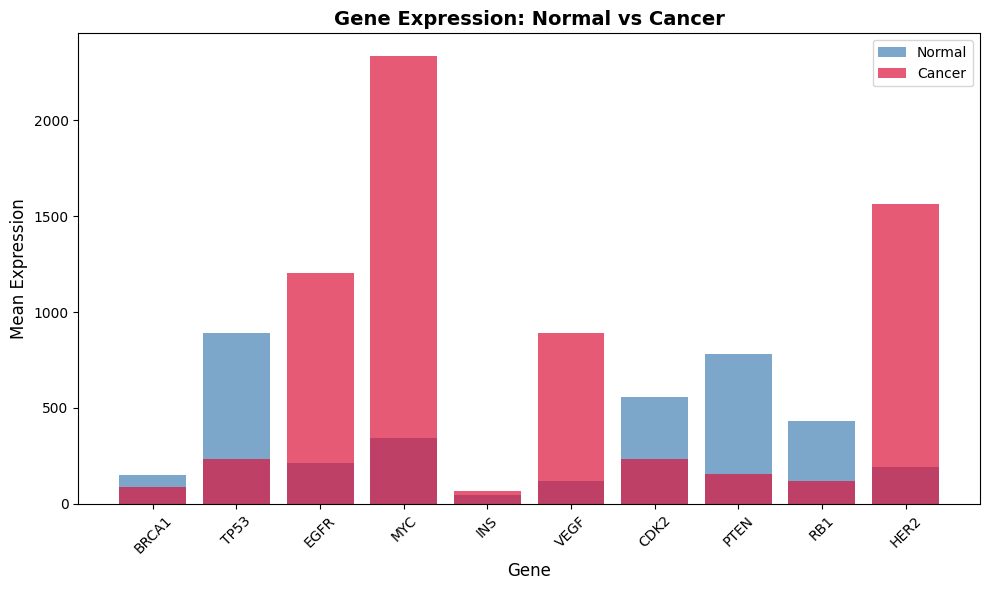

✅ Plot saved!


In [8]:
# BAR CHART — Gene Expression Comparison

fig, ax = plt.subplots(figsize=(10, 6))
# ↑ fig = the whole figure (like a canvas)
# ↑ ax  = the actual plot area (like paper on canvas)
# ↑ figsize=(10,6) = width=10 height=6 inches

# Plot normal expression
ax.bar(df["gene"],
       df["normal_mean"],
       label="Normal",
       color="steelblue",
       alpha=0.7)
# ↑ ax.bar() = bar chart
# ↑ x axis = gene names
# ↑ y axis = expression values
# ↑ label  = legend text
# ↑ color  = bar color
# ↑ alpha  = transparency (0=invisible, 1=solid)

# Plot cancer expression (next to normal bars)
ax.bar(df["gene"],
       df["cancer_mean"],
       label="Cancer",
       color="crimson",
       alpha=0.7,
       bottom=0)
# ↑ second set of bars

# Labels and title
ax.set_title("Gene Expression: Normal vs Cancer",
             fontsize=14, fontweight="bold")
# ↑ title at top

ax.set_xlabel("Gene", fontsize=12)
# ↑ x axis label

ax.set_ylabel("Mean Expression", fontsize=12)
# ↑ y axis label

ax.legend()
# ↑ show the legend (Normal/Cancer labels)

ax.tick_params(axis="x", rotation=45)
# ↑ rotate gene names 45 degrees so they fit

plt.tight_layout()
# ↑ adjusts spacing so nothing overlaps

plt.savefig("expression_comparison.png", dpi=150)
# ↑ save as image file
# ↑ dpi=150 = resolution (higher = sharper)

plt.show()
# ↑ display the plot
print("✅ Plot saved!")

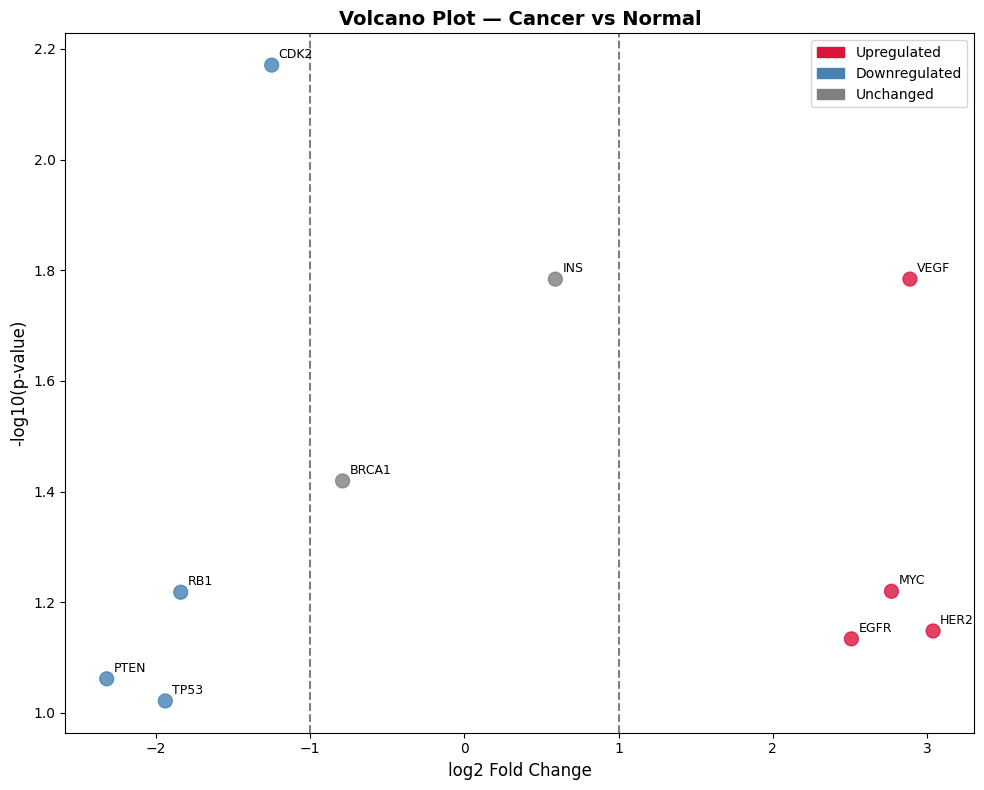

✅ Volcano plot saved!


In [9]:
# VOLCANO PLOT — The Most Important RNA-seq Plot

# Add fake p-values for simulation
np.random.seed(42)
df["pvalue"] = np.random.uniform(0.001, 0.1, len(df))
# ↑ random p-values between 0.001 and 0.1
# ↑ in real analysis these come from DESeq2

df["neg_log10_pval"] = -np.log10(df["pvalue"])
# ↑ -log10(pvalue) = standard transformation
# ↑ smaller pvalue = bigger this number = higher on plot

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Color each point based on regulation
colors = []
for reg in df["regulation"]:
    if reg == "upregulated":
        colors.append("crimson")    # red
    elif reg == "downregulated":
        colors.append("steelblue")  # blue
    else:
        colors.append("gray")       # gray

# Plot all genes as dots
ax.scatter(df["log2_fc"],
           df["neg_log10_pval"],
           c=colors,
           s=100,
           alpha=0.8)
# ↑ scatter = dot plot
# ↑ x = log2fc, y = significance
# ↑ c = colors list
# ↑ s = dot size

# Add gene name labels
for i, row in df.iterrows():
# ↑ .iterrows() = loop through DataFrame rows
# ↑ i = row index number
# ↑ row = all data for that row

    ax.annotate(row["gene"],
                (row["log2_fc"],
                 row["neg_log10_pval"]),
                fontsize=9,
                xytext=(5, 5),
                textcoords="offset points")
    # ↑ add gene name next to each dot

# Reference lines
ax.axvline(x=1,  color="black",
           linestyle="--", alpha=0.5)
ax.axvline(x=-1, color="black",
           linestyle="--", alpha=0.5)
# ↑ vertical dashed lines at log2FC = ±1

# Labels
ax.set_title("Volcano Plot — Cancer vs Normal",
             fontsize=14, fontweight="bold")
ax.set_xlabel("log2 Fold Change", fontsize=12)
ax.set_ylabel("-log10(p-value)", fontsize=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color="crimson",   label="Upregulated"),
    Patch(color="steelblue", label="Downregulated"),
    Patch(color="gray",      label="Unchanged")
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("volcano_plot.png", dpi=150)
plt.show()
print("✅ Volcano plot saved!")

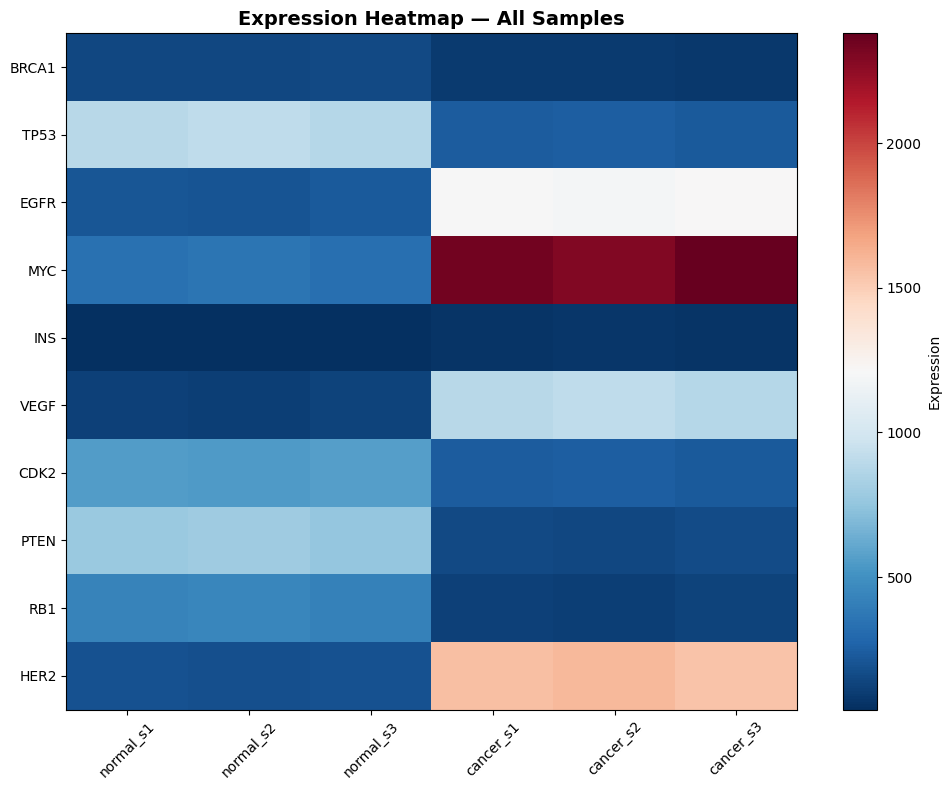

✅ Heatmap saved!


In [10]:
# HEATMAP — Expression Across All Samples

fig, ax = plt.subplots(figsize=(10, 8))

# Select sample columns only
sample_cols = ["normal_s1", "normal_s2", "normal_s3",
               "cancer_s1", "cancer_s2", "cancer_s3"]

heatmap_data = df.set_index("gene")[sample_cols]
# ↑ set_index("gene") = use gene names as row labels

# Create heatmap using imshow
im = ax.imshow(heatmap_data,
               cmap="RdBu_r",
               aspect="auto")
# ↑ imshow = display data as colored grid
# ↑ cmap="RdBu_r" = Red-Blue colormap
#   red = high expression
#   blue = low expression

# Add colorbar
plt.colorbar(im, ax=ax, label="Expression")
# ↑ shows what colors mean

# Labels
ax.set_xticks(range(len(sample_cols)))
ax.set_xticklabels(sample_cols, rotation=45)
# ↑ column labels

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["gene"])
# ↑ row labels (gene names)

ax.set_title("Expression Heatmap — All Samples",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()
print("✅ Heatmap saved!")

In [12]:
# Download all plots
from google.colab import files
files.download("expression_comparison.png")
files.download("volcano_plot.png")
files.download("heatmap.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>